In [48]:
# imPORT LIBRARIES 
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from math import pi, sqrt
import handcalcs.render
import pandas as pd
import json 
# !pip install handcalcs

In [49]:
%%render 
Lr = 21e-6 #uH
Lm = 83e-6 # uH
Cr = 120e-9
Ln= Lm/Lr
Fr= 1/(2*pi*sqrt(Lr*Cr))


<IPython.core.display.Latex object>

In [3]:
%%render 
n=4
Rload=22
Re = 8*n**2*Rload / (pi**2)

Qe = sqrt(Lr/Cr)/Re

<IPython.core.display.Latex object>

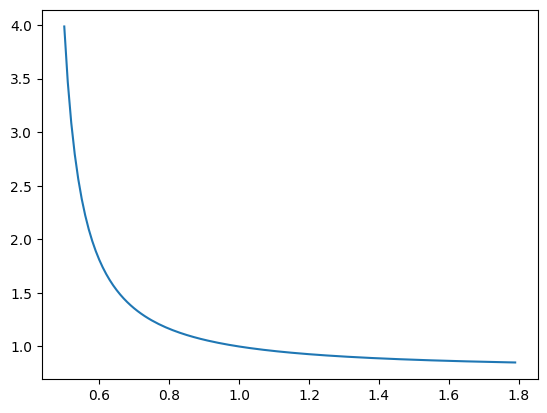

In [4]:
def calculate_Mg(Ln, fn, Qe):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = abs(numerator / denominator)
    return Mg
fn = np.arange(0.5,1.8,0.01) 
#Lnc=3 
#Qe = 0.55 
Mg= calculate_Mg(Ln, fn, Qe)
plt.plot(fn, Mg)

In [5]:
t= """155	37.3
147	37.7
121	38.55
110.9	40.48
91.25	44.19
79.91	47.02
77.83	48.88""".split("\n")
t=[x.split("\t") for x in t]
df= pd.DataFrame(t, columns =["F", "Vout"]).astype("float32")
df["F"]=df["F"]*1000
df

,F,Vout
0,155000.0,37.299999
1,147000.0,37.700001
2,121000.0,38.549999
3,110900.0,40.480000
4,91250.0,44.189999
5,79910.0,47.020000
6,77830.0,48.880001


<Axes: xlabel='F'>

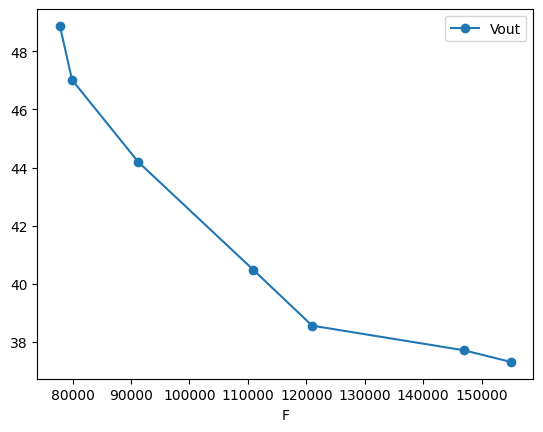

In [6]:
df.plot(x="F", y="Vout", marker = "o")

,F,Vout,Mg,fn,MgTheo
0,155000.0,37.299999,0.864928,1.546008,0.871146
1,147000.0,37.700001,0.874203,1.466214,0.880357
2,121000.0,38.549999,0.893913,1.206884,0.926397
3,110900.0,40.480000,0.938667,1.106144,0.955777
4,91250.0,44.189999,1.024696,0.910150,1.055275
5,79910.0,47.020000,1.090319,0.797042,1.169585
6,77830.0,48.880001,1.133449,0.776296,1.199750


<Axes: xlabel='fn'>

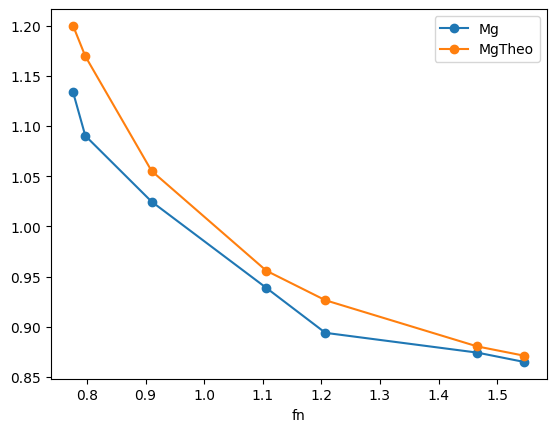

In [7]:
Mg= calculate_Mg(Ln, fn, Qe)
Vin = 345
df["Mg"]= n*df["Vout"]/(Vin /2)
df["fn"]= df["F"]/Fr
df["MgTheo"]= calculate_Mg(Ln, df["fn"].values, Qe)
display(df)
df.plot(x="fn", y=["Mg", "MgTheo"], marker = "o")

# Optimize Qe Ln K 

In [26]:
def calculate_Mg(Ln, fn, Qe, K=1):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = K*abs(numerator / denominator)
    return Mg
Qe, Ln =(0.04636455749977099, 3.9523809523809526)
fn = df["fn"].values
Mg= df["Mg"].values
K= 1
def obj (Ln , Qe, K): 
    Mgcal = calculate_Mg(Ln, fn, Qe, K)
    return np.abs(Mgcal-Mg).sum()
# test 
obj (Ln , Qe, K)

np.float32(0.2381131)

In [27]:
import numpy as np
from scipy.optimize import minimize

# initial guess
x0 = [Ln, Qe, K]

# wrapper for 3 parameters
def obj_wrap(x):
    Ln_, Qe_, K_ = x
    return obj(Ln_, Qe_, K_)

# bounds (strongly recommended)
bounds = [
    (0.01, 50),     # Ln
    (1e-4, 10),     # Qe
    (0.01, 10)      # K
]

# optimization
res = minimize(
    obj_wrap,
    x0,
    method="Powell",     # stable for non-linear problems
    bounds=bounds
)

Ln_opt, Qe_opt, K_opt = res.x

print("Ln_opt =", Ln_opt)
print("Qe_opt =", Qe_opt)
print("K_opt  =", K_opt)
print("Objective =", res.fun)


Ln_opt = 4.673384433595651
Qe_opt = 0.08336547955583862
K_opt  = 0.9747287041273415
Objective = 0.04571811171500417


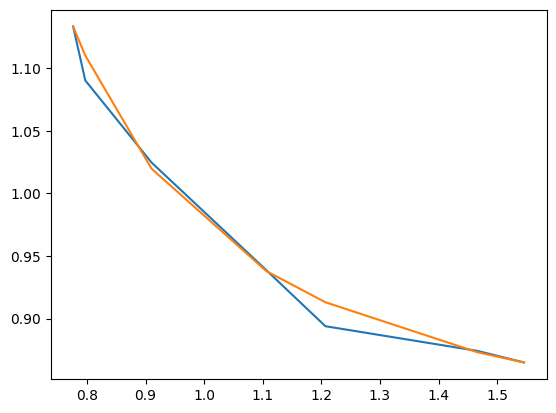

In [34]:
Mg2 = calculate_Mg(Ln_opt, fn, Qe_opt, K_opt)
plt.plot(fn, Mg)
plt.plot(fn, Mg2)

# Optimize Qe Ln K Fr

In [56]:
def calculate_Mg(Ln, fn, Qe, K=1):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = K*abs(numerator / denominator)
    return Mg
Qe, Ln =(0.04636455749977099, 3.9523809523809526)
F = df["F"].values
Mg= df["Mg"].values
K= 1
def obj (Ln , Qe, K, fr): 
    fn = F/fr
    Mgcal = calculate_Mg(Ln, fn, Qe, K)
    return np.abs(Mgcal-Mg).sum()
# test 
fr=100e3
obj (Ln , Qe, K, fr)

np.float32(0.22785598)

In [63]:
import numpy as np
from scipy.optimize import minimize

# initial guess
x0 = [Ln, Qe, K, fr]

# wrapper for 3 parameters
def obj_wrap(x):
    Ln_, Qe_, K_, fr_ = x
    return obj(Ln_, Qe_, K_, fr_)

# bounds (strongly recommended)
bounds = [
    (2,6 ),     # Ln
    (1e-4, 0.1),     # Qe
    (0.9, 1.1),       # K
    (80e3, 120e3) # Fr
]

# optimization
res = minimize(
    obj_wrap,
    x0,
    method="Powell",     # stable for non-linear problems
    bounds=bounds
)

Ln_opt, Qe_opt, K_opt, fr_opt= res.x

print("Ln_opt =", Ln_opt)
print("Qe_opt =", Qe_opt)
print("K_opt  =", K_opt)
print("fr_opt  =", fr_opt)
print("Objective =", res.fun)


Ln_opt = 4.3705330023102675
Qe_opt = 0.09880265526393818
K_opt  = 0.9881661662971291
fr_opt  = 97371.50596930961
Objective = 0.04496018199588492


In [64]:
82/Ln_opt

np.float64(18.76201368497955)

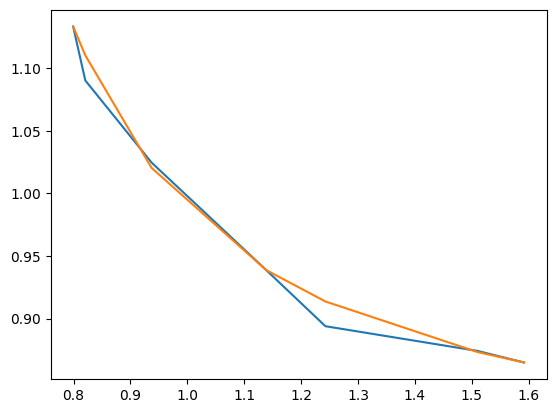

In [65]:
fn = F/fr_opt
Mg2 = calculate_Mg(Ln_opt, fn, Qe_opt, K_opt)
plt.plot(fn, Mg)
plt.plot(fn, Mg2)

In [50]:
#Ln=3.9523809523809526

3.9523809523809526

# Optimize Qe K Fr

In [52]:
Ln=3.9523809523809526
def obj (Qe, K, fr): 
    fn = F/fr
    Mgcal = calculate_Mg(Ln, fn, Qe, K)
    return np.abs(Mgcal-Mg).sum()
# test 

obj ( Qe, K, fr)

np.float32(0.22785598)

In [53]:
import numpy as np
from scipy.optimize import minimize

# initial guess
x0 = [Qe, K, fr]

# wrapper for 3 parameters
def obj_wrap(x):
    Qe_, K_, fr_ = x
    return obj( Qe_, K_, fr_)

# bounds (strongly recommended)
bounds = [
    #(2, 6),     # Ln
    (1e-4, 0.1),     # Qe
    (0.9, 1.1),       # K
    (80e3, 120e3) # Fr
]

# optimization
res = minimize(
    obj_wrap,
    x0,
    method="Powell",     # stable for non-linear problems
    bounds=bounds
)

Qe_opt, K_opt, fr_opt= res.x

#print("Ln_opt =", Ln_opt)
print("Qe_opt =", Qe_opt)
print("K_opt  =", K_opt)
print("fr_opt  =", fr_opt)
print("Objective =", res.fun)


Qe_opt = 0.00010000000000821521
K_opt  = 0.9740598887575526
fr_opt  = 97088.34591544412
Objective = 0.09597681950442338


In [55]:
Ln

3.9523809523809526

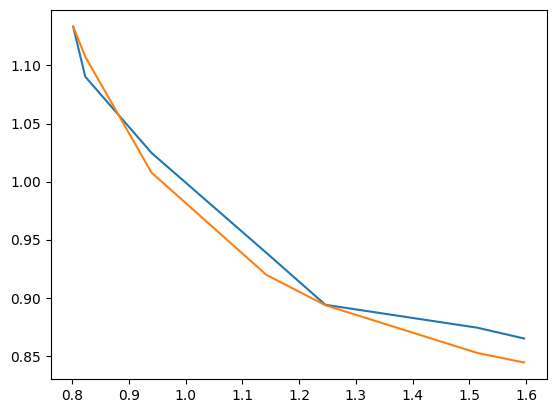

In [54]:
fn = F/fr_opt
Mg2 = calculate_Mg(Ln,  fn, Qe_opt, K_opt)
plt.plot(fn, Mg)
plt.plot(fn, Mg2)

In [57]:
from math import *

#############" Input
Nbits =9
V_by_div=0.2
Vertical_range = V_by_div*10
t_div= 20e-6
N_horiz_points= 10_000
rbw= 9e3
#################


Horiz_range =t_div*10
Resolution = Vertical_range/2**Nbits 

db_uv_max= 20*log10(1e6*Vertical_range/2)
db_uv_min= 20*log10(1e6*Resolution )
print("#", Horiz_range, Resolution , Vertical_range, db_uv_max, db_uv_min)




# --- B. Design the "RBW" Window ---
# We need a Gaussian window where the 6dB bandwidth equals RBW.


Ts = Horiz_range/N_horiz_points
fs=1/Ts
sigma_f = rbw / (2 * sqrt(2 * log(2)))
sigma_t = 1.0 / (2 * pi * sigma_f)

# Window length (Physical Filter Width)
win_len_sec = 6 * sigma_t 
nperseg = int(win_len_sec * fs)
Min_FFT = Resolution/sqrt(nperseg)
db_uv_min= 20*log10(1e6*Min_FFT)

################### Output
print('#', Min_FFT, db_uv_min)

# 0.0002 0.00390625 2.0 120.0 71.83520069376301
# 3.494974785774863e-05 30.868880938181398

# 0.0002 0.00390625 2.0 120.0 71.83520069376301
# 3.494974785774863e-05 30.868880938181398


In [63]:
from math import *

#############" Input
Nbits =9
V_by_div=0.2
Vertical_range = V_by_div*10
t_div= 20e-6
N_horiz_points= 10_000
rbw= 9e3
#################


Horiz_range =t_div*10
Resolution = Vertical_range/2**Nbits 

db_uv_max= 20*log10(1e6*Vertical_range/2)
db_uv_min0= 20*log10(1e6*Resolution )





# --- B. Design the "RBW" Window ---
# We need a Gaussian window where the 6dB bandwidth equals RBW.


Ts = Horiz_range/N_horiz_points
fs=1/Ts
sigma_f = rbw / (2 * sqrt(2 * log(2)))
sigma_t = 1.0 / (2 * pi * sigma_f)

# Window length (Physical Filter Width)
win_len_sec = 6 * sigma_t 
nperseg = int(win_len_sec * fs)
Min_FFT = Resolution/sqrt(nperseg)
db_uv_min= 20*log10(1e6*Min_FFT)

################### Output
print("#", Horiz_range, Resolution , Vertical_range, db_uv_max, db_uv_min0)
print('#', Min_FFT, db_uv_min, Ts , Horiz_range, fs)

# 0.0002 0.00390625 2.0 120.0 71.83520069376301
# 3.494974785774863e-05 30.868880938181398

# 0.0002 0.00390625 2.0 120.0 71.83520069376301
# 3.494974785774863e-05 30.868880938181398 2e-08 0.0002 50000000.0
